In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [17]:
# 1. 读取数据
file_path = 'C:/Users/yolo/Desktop/天气数据.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

print("数据预览：")
print(df.head())
print("\n数据统计信息：")
print(df.describe())

数据预览：
     年份    北京    上海    武汉    广州    成都  哈尔滨  乌鲁木齐    海口
0  2014  14.1  17.0  16.7  21.7  16.0  7.7   7.4  24.7
1  2015  12.8  17.6  17.1  21.5  16.9  7.3   8.7  24.3
2  2016  12.6  17.2  16.6  22.5  14.6  4.5   7.4  24.6
3  2017  15.8  17.0  18.0  20.8  15.9  5.5   7.3  24.5
4  2018  13.4  18.1  17.3  22.8  16.3  6.9   7.7  24.8

数据统计信息：
                年份         北京         上海         武汉         广州         成都  \
count    11.000000  11.000000  11.000000  11.000000  11.000000  11.000000   
mean   2019.000000  13.809091  17.281818  16.736364  21.845455  16.118182   
std       3.316625   1.296499   0.423835   0.574931   0.610514   0.607977   
min    2014.000000  12.000000  16.500000  15.900000  20.800000  14.600000   
25%    2016.500000  12.750000  17.000000  16.400000  21.550000  15.950000   
50%    2019.000000  13.500000  17.200000  16.700000  21.700000  16.200000   
75%    2021.500000  14.700000  17.550000  16.950000  22.250000  16.350000   
max    2024.000000  15.800000  18.10000

In [19]:
# 2. 数据预处理：提取年份
first_col_name = df.columns[0]
df.rename(columns={first_col_name: '年份'}, inplace=True)

# 确保年份列为数字（如果读成字符串则转换）
df['年份'] = pd.to_numeric(df['年份'], errors='coerce')
# 删除年份为空的行（如果年份无法解析）
df = df.dropna(subset=['年份'])
df['年份'] = df['年份'].astype(int)

print("处理后的列名：", df.columns.tolist())
print("年份范围：", df['年份'].min(), "-", df['年份'].max())

处理后的列名： ['年份', '北京', '上海', '武汉', '广州', '成都', '哈尔滨', '乌鲁木齐', '海口']
年份范围： 2014 - 2024


In [20]:
# 3. 定义城市列表（自动获取除“年份”外的所有列）
cities = [col for col in df.columns if col != '年份']
print("识别到的城市列表：", cities)

识别到的城市列表： ['北京', '上海', '武汉', '广州', '成都', '哈尔滨', '乌鲁木齐', '海口']


In [21]:
# 4. 检查缺失值并用线性插值填充
print("\n缺失值统计：")
print(df[cities].isnull().sum())

# 对每个城市列进行插值
for city in cities:
    df[city] = df[city].interpolate(method='linear', limit_direction='both')

# 检查是否还有缺失（如果有，用前后均值填充）
df[cities] = df[cities].fillna(df[cities].mean())


缺失值统计：
北京      0
上海      0
武汉      0
广州      0
成都      0
哈尔滨     0
乌鲁木齐    0
海口      0
dtype: int64


In [22]:
# 5. 计算全国平均气温
df['全国平均'] = df[cities].mean(axis=1)

In [23]:
# 6. 计算各城市的变暖趋势（斜率）
def calc_trend(series):
    x = np.arange(len(series))
    slope = np.polyfit(x, series, 1)[0]
    return slope

trends = {}
for city in cities:
    trends[city] = calc_trend(df[city])

trend_df = pd.DataFrame(list(trends.items()), columns=['城市', '变暖趋势(°C/年)'])
trend_df = trend_df.sort_values(by='变暖趋势(°C/年)', ascending=False)
print("\n各城市变暖趋势：")
print(trend_df)


各城市变暖趋势：
     城市  变暖趋势(°C/年)
5   哈尔滨    0.065455
4    成都    0.048182
3    广州    0.021818
1    上海    0.000909
0    北京   -0.001818
7    海口   -0.029091
6  乌鲁木齐   -0.093636
2    武汉   -0.105455


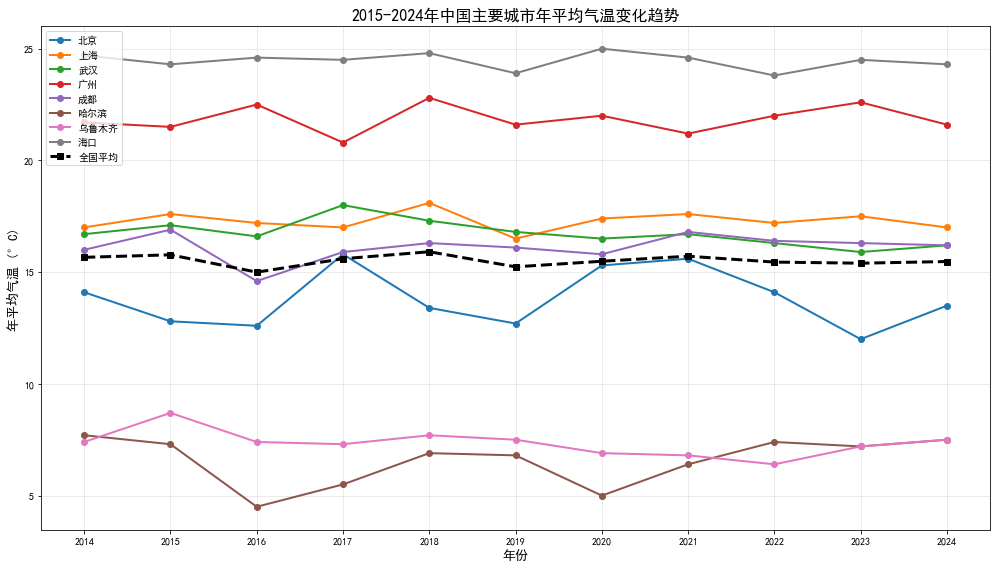

In [24]:
# 7. 可视化：各城市气温趋势（折线图）
plt.figure(figsize=(14, 8))

for city in cities:
    plt.plot(df['年份'], df[city], marker='o', linewidth=2, label=city)

plt.plot(df['年份'], df['全国平均'], marker='s', linewidth=3, 
         color='black', linestyle='--', label='全国平均')

plt.title('2015-2024年中国主要城市年平均气温变化趋势', fontsize=16)
plt.xlabel('年份', fontsize=13)
plt.ylabel('年平均气温 (°C)', fontsize=13)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(df['年份'])
plt.tight_layout()
plt.savefig('图1_各城市气温趋势.png', dpi=300)
plt.show()

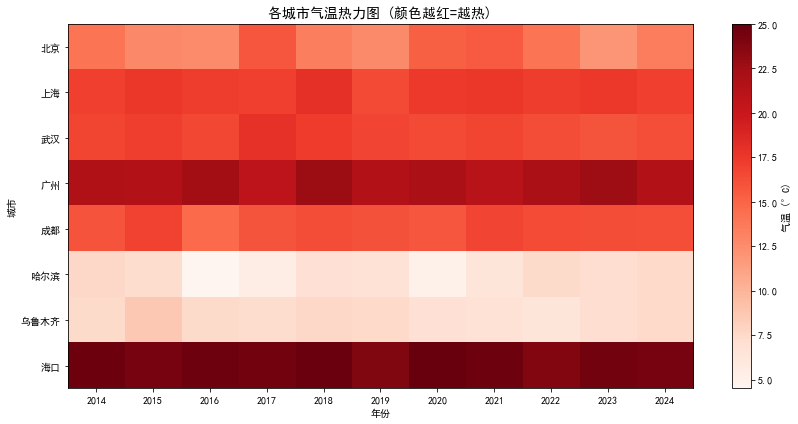

In [25]:
# 8. 可视化：热力图（城市 vs 年份）
# ====================================================================
plt.figure(figsize=(12, 6))
data_matrix = df[cities].T
plt.imshow(data_matrix, cmap='Reds', aspect='auto')

plt.colorbar(label='气温 (°C)')
plt.xticks(np.arange(len(df['年份'])), df['年份'])
plt.yticks(np.arange(len(cities)), cities)
plt.title('各城市气温热力图 (颜色越红=越热)', fontsize=14)
plt.xlabel('年份')
plt.ylabel('城市')
plt.tight_layout()
plt.savefig('图2_气温热力图.png', dpi=300)
plt.show()


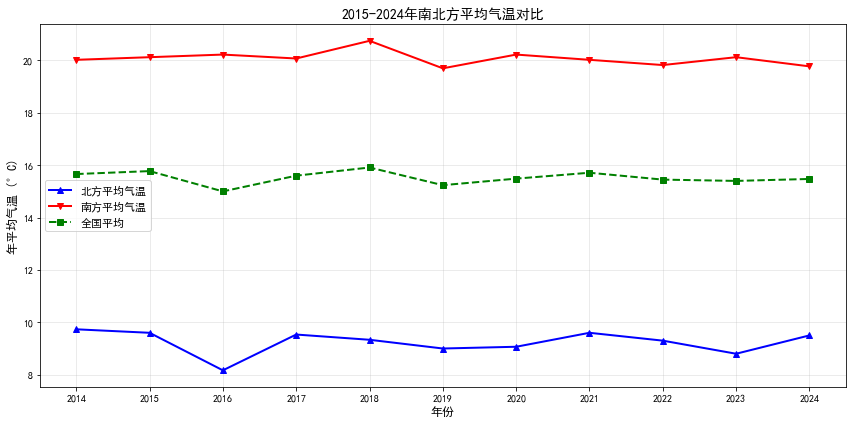

In [26]:
# 9. 可视化：南北城市对比
# ====================================================================
# 简单划分：北方（北京、哈尔滨、乌鲁木齐），南方（上海、武汉、广州、海口）
north_cities = ['北京', '哈尔滨', '乌鲁木齐']
south_cities = ['上海', '武汉', '广州', '海口']
north_cities = [c for c in north_cities if c in cities]
south_cities = [c for c in south_cities if c in cities]

if north_cities:
    df['北方平均'] = df[north_cities].mean(axis=1)
if south_cities:
    df['南方平均'] = df[south_cities].mean(axis=1)

plt.figure(figsize=(12, 6))
if north_cities:
    plt.plot(df['年份'], df['北方平均'], marker='^', linewidth=2, 
             color='blue', label='北方平均气温')
if south_cities:
    plt.plot(df['年份'], df['南方平均'], marker='v', linewidth=2, 
             color='red', label='南方平均气温')
plt.plot(df['年份'], df['全国平均'], marker='s', linewidth=2, 
         color='green', linestyle='--', label='全国平均')

plt.title('2015-2024年南北方平均气温对比', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('年平均气温 (°C)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(df['年份'])
plt.tight_layout()
plt.savefig('图3_南北方对比.png', dpi=300)
plt.show()

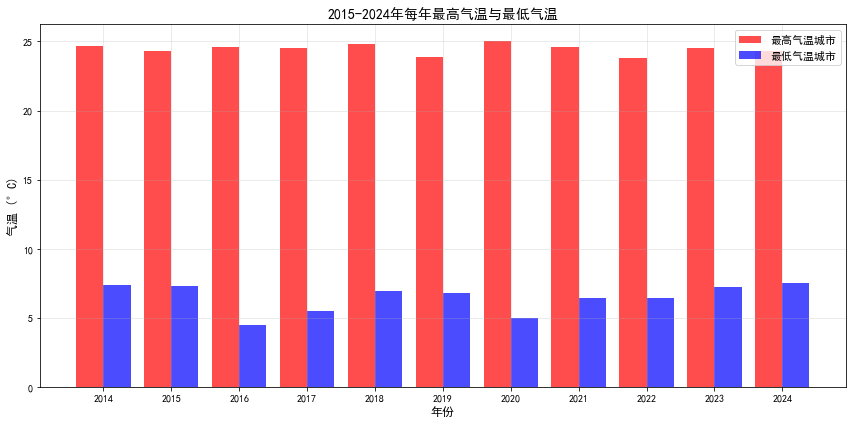

In [27]:
# 可视化：极值分析（最高温和最低温城市）
# ====================================================================
if len(cities) >= 2:
    plt.figure(figsize=(12, 6))
    # 找到每年最热和最冷的城市
    max_temp = df[cities].max(axis=1)
    min_temp = df[cities].min(axis=1)

    plt.bar(df['年份'] - 0.2, max_temp, width=0.4, 
            color='red', alpha=0.7, label='最高气温城市')
    plt.bar(df['年份'] + 0.2, min_temp, width=0.4, 
            color='blue', alpha=0.7, label='最低气温城市')

    plt.title('2015-2024年每年最高气温与最低气温', fontsize=14)
    plt.xlabel('年份', fontsize=12)
    plt.ylabel('气温 (°C)', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(df['年份'])
    plt.tight_layout()
    plt.savefig('图4_极值分析.png', dpi=300)
    plt.show()


In [28]:
# 11. 输出关键结论
print("\n" + "="*50)
print("关键分析结论")
print("="*50)
hottest = df[cities].mean().idxmax()
coldest = df[cities].mean().idxmin()
fastest = trend_df.iloc[0]['城市']
print(f"1. 最热城市：{hottest}（平均 {df[cities].mean().max():.1f}°C）")
print(f"2. 最冷城市：{coldest}（平均 {df[cities].mean().min():.1f}°C）")
print(f"3. 升温最快：{fastest}（每10年约 {trend_df.iloc[0]['变暖趋势(°C/年)']*10:.2f}°C）")
if len(df) >= 6:
    recent = df.head(3)[cities].mean().mean()
    past = df.tail(3)[cities].mean().mean()
    print(f"4. 最近3年比最早3年气温上升 {past - recent:.2f}°C")



关键分析结论
1. 最热城市：海口（平均 24.5°C）
2. 最冷城市：哈尔滨（平均 6.6°C）
3. 升温最快：哈尔滨（每10年约 0.65°C）
4. 最近3年比最早3年气温上升 -0.04°C
